In [15]:
# For each approach and parallelism level, plot results

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [17]:
def plotResults(df, title):


    fig, ax = plt.subplots(2,2, figsize=(10,10))

    j = 1
    for i in [10,100,1000]:
        dfBin = df[df["Bins"] == i]

        p = dfBin["Ranks"]
        sp = dfBin.at[j,"Runtime"] / dfBin["Runtime"]
        ep = sp / p

        ax[0,0].plot(p, dfBin["Runtime"], label="Bins:" + str(i))
        ax[0,1].plot(sp, dfBin["Runtime"])
        ax[1,0].plot(ep, dfBin["Runtime"])
        ax[1,1].plot(p, dfBin["Runtime"])

        j += 1

    #plt.xscale("log")
    ax[0,0].set_xlim(0, 64)
    ax[0,0].set_ylim(0,2)

    ax[1,0].set_xscale("log")
    ax[1,0].set_yscale("log")

    ax[1,1].set_xscale("log")
    ax[1,1].set_yscale("log")
    #ax[0,1].set_xlim(0, 64)
    #ax[0,1].set_ylim(0,2)

    ax[0,0].set_title("Runtime vs. Parallelism")
    ax[0,1].set_title("Runtime vs. Speedup")
    ax[1,0].set_title("Runtime vs. Efficiency")
    ax[1,1].set_title("Runtime vs. Parallelism (Full Range)")

    ax[0,0].set_xlabel("Parallelism")
    ax[0,1].set_xlabel("Speedup")
    ax[1,0].set_xlabel("Efficiency (Log Scale)")
    ax[1,1].set_xlabel("Parallelism (Log Scale)")

    ax[0,0].set_ylabel("Runtime")
    ax[1,0].set_ylabel("Runtime (Log Scale)")


    fig.suptitle(title)
    fig.legend()
    fig.tight_layout()
    plt.savefig("./" + title + "Plot.png", format="png")
    plt.show()

    return 0


In [18]:
#keyword = "async"
keyword = "mp"
fname = "/home/biscuit/Documents/utd/phys5v48/phys5v48/phys5v48hw/hw4/output/" + keyword + "Lorentz/" + keyword + "LorentzCat.xlsx"
title = "Multiprocessing"

writer = pd.ExcelWriter(fname, engine='openpyxl', mode='a')
dfAsync = pd.read_excel(writer, index_col=0) # Read in catalog

display(dfAsync)

,Problem Size (n),Bins,Nodes,Ranks,Threads Per Rank,Runtime,Peak Memory
1,100000000,10,2,1,1,3.111363,81324
2,100000000,100,2,1,1,3.009007,81780
3,100000000,1000,2,1,1,2.962339,81728
4,100000000,10,2,2,1,1.531414,82000
5,100000000,100,2,2,1,1.595890,81864
6,100000000,1000,2,2,1,1.498228,81620
7,100000000,10,2,4,1,0.810075,81352
8,100000000,100,2,4,1,0.818013,81684
9,100000000,1000,2,4,1,0.840192,81828
10,100000000,10,2,8,1,0.468271,81652


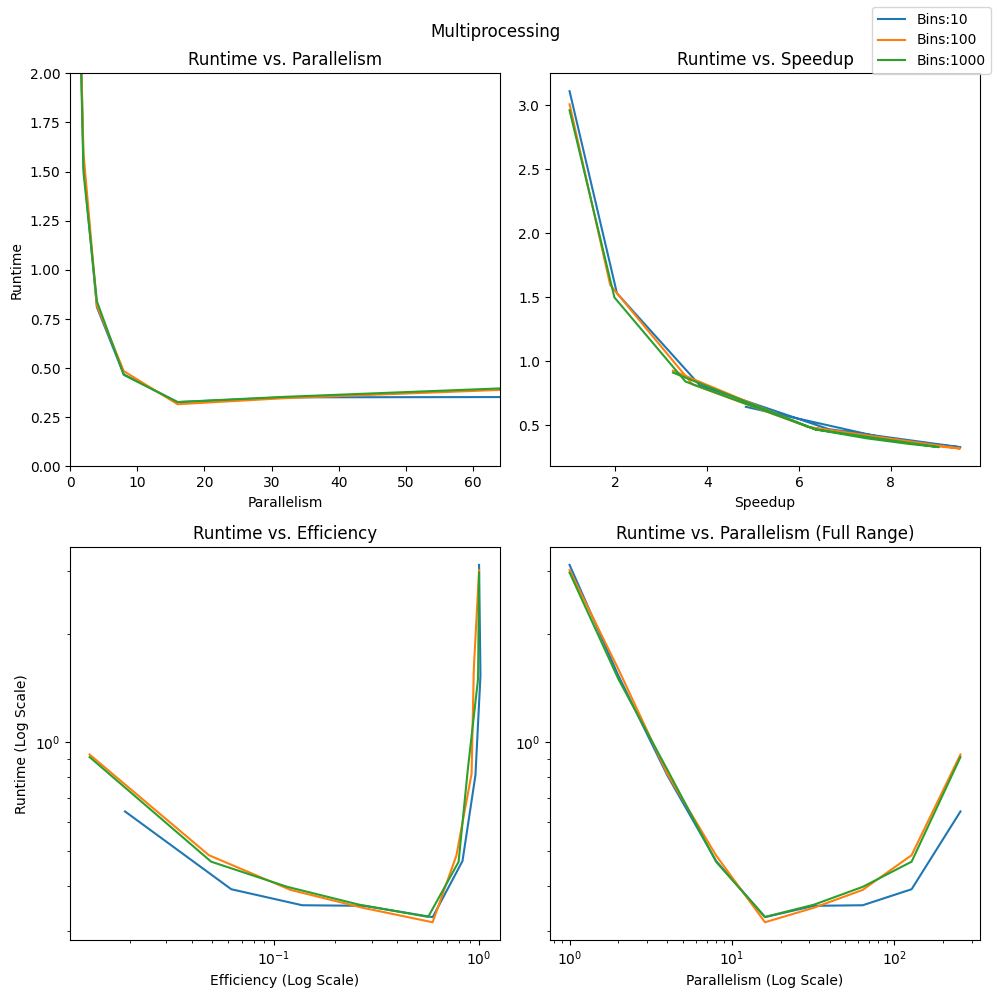

0

In [19]:
plotResults(dfAsync, title)
